## Communication Subspace Analysis Between Two Regions

**Created:** Friday, January 16, 2026, 14:58:05  
**Author:** @nehabinish  

This notebook demonstrates the identification of a communication subspace between two brain regions (R1 and R2).

In [1]:
# %% == Autoreload ==

# Run cell to enable autoreload of modules
%load_ext autoreload
%autoreload 2

In [2]:
# %% == Get working dir to set path ==

import os
import sys

try:
    from pathlib import Path # Try using pathlib 
    cwd = Path.cwd()         # Current working directory
    parent_dir = cwd.parent  # Parent directory

    # Add parent directory to system path
    sys.path.append(str(parent_dir))
    sys.path.append(str(parent_dir / 'src/'))

except Exception as e:
    # Fallback using os module if pathlib fails
    try:
        cwd = os.getcwd()
        parent_dir = os.path.dirname(cwd)

        sys.path.append(parent_dir)
        sys.path.append(os.path.join(parent_dir, 'src'))
    except Exception as ex:
        print("Could not determine workspace paths automatically.")
        print("Please ensure you are running the notebook in a proper directory.")
        print("If error persists, manually set cwd and parent_dir.")
        print("Error details:", ex)

# Notes for users:
# 1. Make sure your notebook is launched from the root project folder
#    so that the parent directory contains your modules.
# 2. If cell fails, manually set 'cwd' and 'parent_dir' at the top.
# 3. This setup is crucial for importing custom modules located in the parent directory.

In [3]:
# %% == Import modules ==

# Python standard libraries
import pickle
import numpy as np
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold

# Custom modules
import init as In
from commsub_utils import RRR

# Set random seeds for reproducibility
rng = np.random.default_rng(42)

In [4]:
# %% == Load synthetic example data ==

data_path = os.path.join(parent_dir, 'data', 'demo_data.pkl')
with open(data_path, 'rb') as f:
    data = pickle.load(f)

In [5]:
# %% == Functions to compute communication subspace ==

# Function to split data by trial types
def split_data_trials_by_key(
    data,
    trial_key="trial_type",
    predictive_label=None,
    random_label=None,
    verbose=True,
):
    """
    Split trial data into predictive and random sets based on trial labels.
    Args:
        data (dict): Must contain 'R1', 'R2', and trial_key
        trial_key (str): Key specifying trial labels
        predictive_label: Label(s) for predictive trials
        random_label: Label(s) for random trials
        verbose (bool): Print diagnostic info

    Returns:
        dict with keys:
            X_prd, X_rnd, Y_prd, Y_rnd, prd_idx, rnd_idx
    """
    if trial_key not in data:
        raise KeyError(f"'{trial_key}' not found in data.")

    trial_labels = np.asarray(data[trial_key])

    # Normalize labels
    if predictive_label is not None and not isinstance(predictive_label, (list, tuple, np.ndarray)):
        predictive_label = [predictive_label]
    if random_label is not None and not isinstance(random_label, (list, tuple, np.ndarray)):
        random_label = [random_label]

    if predictive_label is not None and random_label is not None:
        prd_idx = np.where(np.isin(trial_labels, predictive_label))[0]
        rnd_idx = np.where(np.isin(trial_labels, random_label))[0]
    else:
        # Raise error if labels are not provided
        raise ValueError("Both predictive_label and random_label must be provided for splitting.")

    X_prd = data["R1"][prd_idx]
    X_rnd = data["R1"][rnd_idx]
    Y_prd = data["R2"][prd_idx]
    Y_rnd = data["R2"][rnd_idx]

    if verbose:
        print(f"Predictive trials: {len(prd_idx)} | Random trials: {len(rnd_idx)}")
        print(f"R1: {X_prd.shape} (prd), {X_rnd.shape} (rnd)")
        print(f"R2: {Y_prd.shape} (prd), {Y_rnd.shape} (rnd)")

    return {
        "X_prd": X_prd,
        "X_rnd": X_rnd,
        "Y_prd": Y_prd,
        "Y_rnd": Y_rnd,
    }

# Function to compute condition-averaged source and target matrices
def compute_condition_averages(X_prd, X_rnd, Y_prd, Y_rnd, verbose=True):
    """
    Compute condition-averaged source and target matrices.

    Args:
        X_prd (np.ndarray): Predictive source data 
        X_rnd (np.ndarray): Random source data 
        Y_prd (np.ndarray): Predictive target data 
        Y_rnd (np.ndarray): Random target data 
        verbose (bool): Print shapes
    Returns:
        Source, Target: arrays of shape [(conditions*time) x channels]
    """
    X_prd_avg = np.mean(X_prd, axis=0)
    X_rnd_avg = np.mean(X_rnd, axis=0)
    Y_prd_avg = np.mean(Y_prd, axis=0)
    Y_rnd_avg = np.mean(Y_rnd, axis=0)

    Xsource = [
        np.concatenate([X_prd_avg[ch], X_rnd_avg[ch]])
        for ch in range(X_prd_avg.shape[0])
    ]
    Ytarget = [
        np.concatenate([Y_prd_avg[ch], Y_rnd_avg[ch]])
        for ch in range(Y_prd_avg.shape[0])
    ]

    Source = np.array(Xsource).T
    Target = np.array(Ytarget).T

    if verbose:
        print(f"Source shape: {Source.shape}")
        print(f"Target shape: {Target.shape}")

    return Source, Target

# Function to run subsampled cross-validated RRR (XY only)
def run_subsample_cv_xy(
    Source,
    Target,
    rng,
    outer_iterations=100,
    cvNumFolds=10,
    p_frac=0.5,
    k_dim=10,
    alpha=0.25,
    verbose=True,
):
    """
    Subsample channels and run cross-validated RRR (XY only).
    Args:
        Source (np.ndarray): Source data matrix 
        Target (np.ndarray): Target data matrix 
        rng (np.random.Generator): Random number generator
        outer_iterations (int): Number of subsampling iterations
        cvNumFolds (int): Number of cross-validation folds
        p_frac (float): Fraction of source channels to sample   
        k_dim (int): Number of target dimensions to sample
        alpha (float): Regularization parameter
        verbose (bool): Print progress
    Returns:
        dict with keys:
            XY_loss_iter: Performance loss for each iteration
            XY_B_iter: Communication subspace weights for each iteration  
    """
    XY_loss_iter, XY_B_iter = [], []

    n_channels = Source.shape[1]
    p = int(n_channels * p_frac)

    for it in range(outer_iterations):
        if verbose:
            print(f"\n[ITER {it + 1}/{outer_iterations}]")

        src_idx = rng.choice(n_channels, p, replace=False)
        Source_sub = Source[:, src_idx]

        tgt_idx = rng.choice(Target.shape[1], k_dim, replace=False)
        Target_sub = Target[:, tgt_idx]

        kf = KFold(n_splits=cvNumFolds, shuffle=True, random_state=it)

        XY_fold, XY_B_fold = [], []

        for fold, (tr, te) in enumerate(kf.split(Source_sub)):
            S_tr, S_te = Source_sub[tr], Source_sub[te]
            T_tr, T_te = Target_sub[tr], Target_sub[te]

            XY_CS = RRR(
                crossval=True,
                Xtrain=S_tr, Ytrain=T_tr,
                Xtest=S_te, Ytest=T_te,
                subject_alpha=alpha,
            )

            dims_xy = np.arange(1, k_dim + 1)
            XY_loss, XY_B, _ = XY_CS.RegressFitAndPredict("RRR", dims_xy)

            XY_fold.append(XY_loss)
            XY_B_fold.append(XY_B)

        XY_loss_iter.append(XY_fold)
        XY_B_iter.append(XY_B_fold)

    return {
        "XY_loss_iter": np.array(XY_loss_iter),
        "XY_B_iter": np.array(XY_B_iter),
    }

# Function to compute performance metrics
def compute_performance(loss_iter, cvNumFolds=10):
    """
    Compute mean, SD, SEM, and full-model performance.
    Args:
        loss_iter (np.ndarray): Array of shape [outer_iterations x cvNumFolds x num_dims + 1]
        cvNumFolds (int): Number of cross-validation folds
    Returns:
        dict with keys:
            bootstrapped_cvl, mean_cv, sd_cv, sem_cv, performance_full, error_full  
    """
    boot = np.mean(loss_iter, axis=0)

    mean_cv = np.mean(boot, axis=0)
    sd_cv = np.std(boot, axis=0)
    sem_cv = sd_cv / np.sqrt(cvNumFolds)

    full_model = boot[:, -1]
    performance_full = 1 - np.mean(full_model)
    error_full = np.std(full_model, ddof=1) / np.sqrt(cvNumFolds)

    return {
        "bootstrapped_cvl": boot,
        "mean_cv": mean_cv,
        "sd_cv": sd_cv,
        "sem_cv": sem_cv,
        "performance_full": performance_full,
        "error_full": error_full,
    }

In [6]:
# %% == Main analysis pipeline ==

# 1) Split trials
split = split_data_trials_by_key(
    data,
    trial_key="trial_type",
    predictive_label="predictive",
    random_label="random",
    verbose=False,
)

# 2) Build source / target matrices
Source, Target = compute_condition_averages(
    split["X_prd"],
    split["X_rnd"],
    split["Y_prd"],
    split["Y_rnd"],
)

# 3) Run subsampled RRR cross-validation
results = run_subsample_cv_xy(
    Source,
    Target,
    rng=rng,
    verbose=False,
)

# 4) Compute performance
XY_opt = compute_performance(results["XY_loss_iter"])
print("\nRESULTS")
print("XY full-model performance:", XY_opt["performance_full"])

Source shape: (6000, 20)
Target shape: (6000, 20)

RESULTS
XY full-model performance: 0.5299048417060331



Optimal XY number of dimensions : 6 with loss: 0.4704698398965411
[INFO] Loaded plot style: /Users/nehabinish/Desktop/ContextIV_paper/AIP/pfc-m1-communication-subspace/src/custom_plotstyle.mplstyle


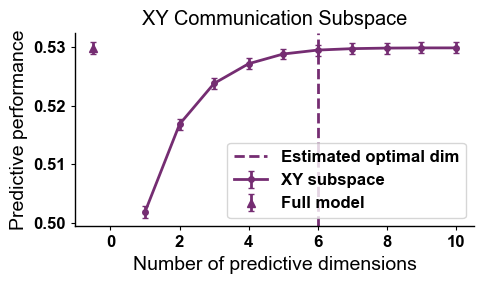

In [7]:
# %% == Plot optimal performance ==
from plot_utils import plot_xy_communication_subspace

# Find Optimal dimensions and loss
xy_result = RRR.model_select(np.array([XY_opt['mean_cv'], XY_opt['sem_cv']]), np.arange(1, 11))
print(f"\nOptimal XY number of dimensions : {xy_result[0]} with loss: {xy_result[1]}")

# Plot results
plot_xy_communication_subspace(XY_opt, np.arange(1, 11), xy_opt_dim=xy_result[0])    